# ModC Week 1 — Linear Regression 1

**Domain:** Marketing Conversion Propensity 
**Dataset:** Google Ads Sales

Baseline OLS, polynomial and interaction terms, and VIF analysis to predict Google Ads campaign conversions.

## 1. Imports and Data Loading

In [33]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

def find_data_root() -> Path:
    marker = 'marketing_and_product_performance.csv'
    for base in [Path.cwd(), *Path.cwd().parents]:
        data_dir = base / 'data'
        if (data_dir / marker).exists():
            return data_dir
    return Path('data')

DATA_ROOT = find_data_root()

DATASET_PATHS = {
    'Marketing and Product Performance': DATA_ROOT / 'marketing_and_product_performance.csv',
    'Predict Conversion in Digital Marketing': DATA_ROOT / 'digital_marketing_campaign_dataset.csv',
    'Google Ads Sales': DATA_ROOT / 'GoogleAds_DataAnalytics_Sales_Uncleaned.csv',
}

def load_dataset(name: str) -> pd.DataFrame:
    path = DATASET_PATHS[name]
    if not path.exists():
        raise FileNotFoundError(
            f"Missing file for '{name}': {path.resolve()}\n"
            f"Current working directory: {Path.cwd()}\n"
            f"Run: python download_datasets.py"
        )
    df = pd.read_csv(path)
    print(f'{name} loaded: {path.name} | shape={df.shape}')
    return df

def pick_column(df, candidates):
    lower_map = {c.lower().replace(' ', '_'): c for c in df.columns}
    for cand in candidates:
        key = cand.lower().replace(' ', '_')
        if key in lower_map:
            return lower_map[key]
    for col in df.columns:
        norm = col.lower().replace(' ', '_')
        if any(cand.lower().replace(' ', '_') in norm for cand in candidates):
            return col
    return None

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'R2': r2_score(y_true, y_pred), 'RMSE': rmse}

def clean_currency(series):
    if series.dtype == object:
        return pd.to_numeric(
            series.astype(str).str.replace(r'[\$,]', '', regex=True),
            errors='coerce',
        )
    return series

def prepare_google_ads_sales(df):
    prepared = df.copy()
    for col in ['Cost', 'Sale_Amount']:
        if col in prepared.columns:
            prepared[col] = clean_currency(prepared[col])

    target_col = pick_column(prepared, ['Conversions', 'Leads', 'Conversion Rate', 'Sale_Amount'])
    if target_col is None or prepared[target_col].notna().sum() < 100:
        raise ValueError('Could not find a suitable regression target in Google Ads Sales.')
    return prepared, target_col

def build_feature_matrix(df, target_col, max_cat_levels=12):
    model_df = df.dropna(subset=[target_col]).copy()
    id_cols = [c for c in model_df.columns if c.lower().endswith('_id') or c.lower() == 'ad_id']
    model_df = model_df.drop(columns=[c for c in id_cols if c != target_col], errors='ignore')
    leakage_cols = ['Conversion Rate', 'Sale_Amount']
    model_df = model_df.drop(columns=[c for c in leakage_cols if c in model_df.columns], errors='ignore')

    cat_cols = model_df.select_dtypes(include=['object', 'category']).columns.tolist()
    for col in cat_cols:
        if col != target_col and model_df[col].nunique() <= max_cat_levels:
            model_df = pd.concat([
                model_df.drop(columns=[col]),
                pd.get_dummies(model_df[col], prefix=col, drop_first=True),
            ], axis=1)

    X = model_df.drop(columns=[target_col]).select_dtypes(include=[np.number])
    X = X.fillna(X.median(numeric_only=True))
    y = model_df[target_col]
    return X, y

google_ads_sales = load_dataset('Google Ads Sales')

Google Ads Sales loaded: GoogleAds_DataAnalytics_Sales_Uncleaned.csv | shape=(2600, 13)


## 2. Exploratory Data Analysis

Dataset: Google Ads Sales
Target column: Conversions
   Ad_ID          Campaign_Name  Clicks  Impressions     Cost  Leads  \
0  A1000    DataAnalyticsCourse   104.0       4498.0  $231.88   14.0   
1  A1001    DataAnalyticsCourse   173.0       5107.0  $216.84   10.0   
2  A1002    Data Anlytics Corse    90.0       4544.0  $203.66   26.0   
3  A1003  Data Analytcis Course   142.0       3185.0  $237.66   17.0   
4  A1004   Data Analytics Corse   156.0       3361.0   $195.9   30.0   

   Conversions  Conversion Rate Sale_Amount     Ad_Date   Location   Device  \
0          7.0            0.058       $1892  2024-11-16  hyderabad  desktop   
1          8.0            0.046       $1679  20-11-2024  hyderabad   mobile   
2          9.0              NaN       $1624  2024/11/16  hyderabad  Desktop   
3          6.0              NaN       $1225  2024-11-26  HYDERABAD   tablet   
4          8.0              NaN       $1091  2024-11-22  hyderabad  desktop   

                  Keyword  
0    learn 

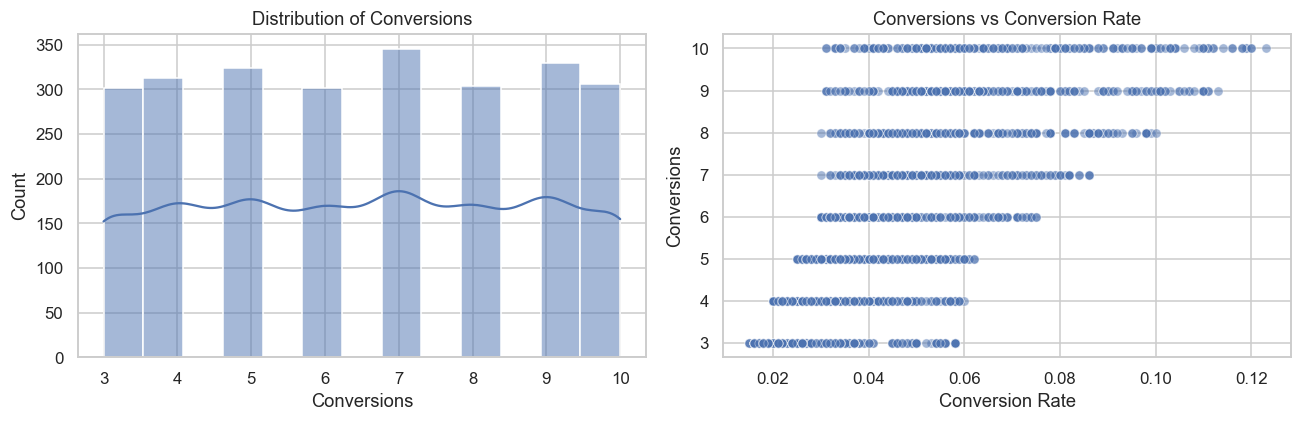

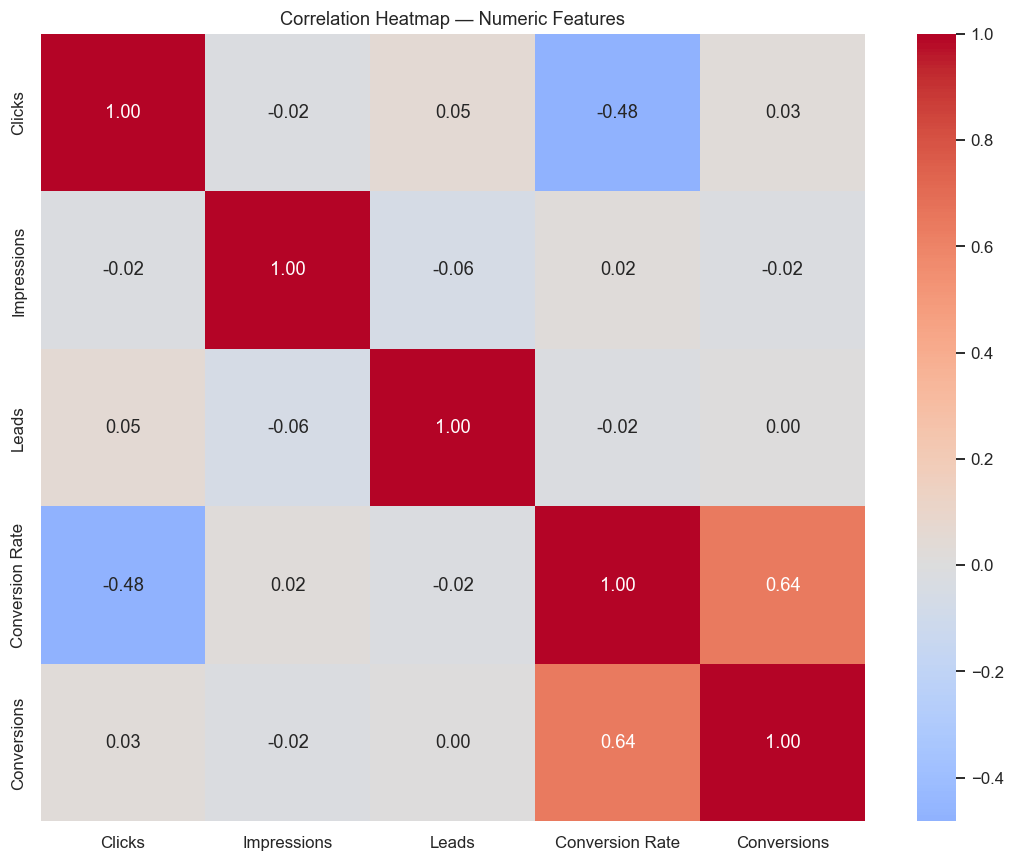

In [34]:

df, target_col = prepare_google_ads_sales(google_ads_sales)
print('Dataset: Google Ads Sales')
print('Target column:', target_col)
print(df.head())

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print('Numeric predictors:', numeric_cols)
print('Categorical predictors:', cat_cols)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[target_col].dropna(), kde=True, ax=axes[0])
axes[0].set_title(f'Distribution of {target_col}')

if len(numeric_cols) >= 1:
    top_pred = df[numeric_cols + [target_col]].corr(numeric_only=True)[target_col].drop(target_col).abs().idxmax()
    sns.scatterplot(data=df, x=top_pred, y=target_col, alpha=0.5, ax=axes[1])
    axes[1].set_title(f'{target_col} vs {top_pred}')
plt.tight_layout()
plt.show()

num_df = df[numeric_cols + [target_col]].dropna()
plt.figure(figsize=(10, 8))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()


## 3. Preprocessing

In [35]:

X, y = build_feature_matrix(df, target_col)
numeric_cols = [c for c in X.columns if c in df.select_dtypes(include=[np.number]).columns]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('Training shape:', X_train.shape, '| Test shape:', X_test.shape)
print('Features:', list(X.columns))


Training shape: (1894, 3) | Test shape: (632, 3)
Features: ['Clicks', 'Impressions', 'Leads']


## 4. Baseline OLS Linear Regression

In [36]:

import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
ols = sm.OLS(y_train, X_train_sm).fit()
print(ols.summary())

y_pred_ols = ols.predict(sm.add_constant(X_test, has_constant='add'))
metrics_ols = regression_metrics(y_test, y_pred_ols)
print('Baseline OLS test metrics:', metrics_ols)


                            OLS Regression Results                            
Dep. Variable:            Conversions   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.182
Date:                Sat, 27 Jun 2026   Prob (F-statistic):              0.315
Time:                        13:52:03   Log-Likelihood:                -4235.6
No. Observations:                1894   AIC:                             8479.
Df Residuals:                    1890   BIC:                             8501.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           6.5730      0.391     16.824      

## 5. Polynomial Terms

Polynomial/interaction base features: ['Leads', 'Impressions', 'Clicks']
Polynomial (degree=2) test metrics: {'R2': -0.004589198582937382, 'RMSE': np.float64(2.2916316565750723)}


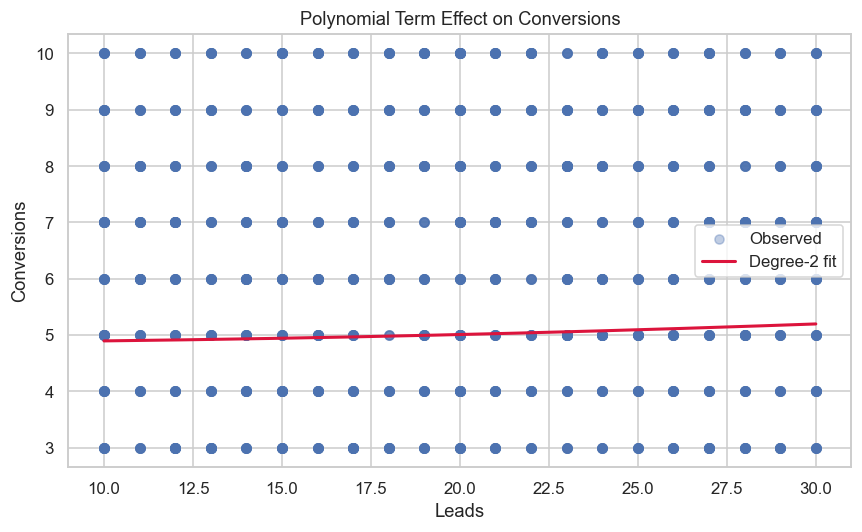

In [37]:

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

poly_candidates = [c for c in X.columns if c in numeric_cols]
if poly_candidates:
    corr_rank = X[poly_candidates].corrwith(y).abs().sort_values(ascending=False)
    poly_base = corr_rank.head(min(3, len(corr_rank))).index.tolist()
else:
    poly_base = X.columns[:3].tolist()
print('Polynomial/interaction base features:', poly_base)

poly_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

X_poly = X[poly_base]
X_poly_train, X_poly_test, y_poly_train, y_poly_test = train_test_split(
    X_poly, y, test_size=0.25, random_state=42
)
poly_pipe.fit(X_poly_train, y_poly_train)
y_pred_poly = poly_pipe.predict(X_poly_test)
metrics_poly = regression_metrics(y_poly_test, y_pred_poly)
print('Polynomial (degree=2) test metrics:', metrics_poly)

if poly_base:
    x_line = np.linspace(X_poly[poly_base[0]].min(), X_poly[poly_base[0]].max(), 200)
    grid = np.zeros((200, len(poly_base)))
    grid[:, 0] = x_line
    y_line = poly_pipe.predict(grid)
    plt.figure(figsize=(8, 5))
    plt.scatter(X_poly[poly_base[0]], y, alpha=0.35, label='Observed')
    plt.plot(x_line, y_line, color='crimson', linewidth=2, label='Degree-2 fit')
    plt.xlabel(poly_base[0])
    plt.ylabel(target_col)
    plt.title(f'Polynomial Term Effect on {target_col}')
    plt.legend()
    plt.tight_layout()
    plt.show()


## 6. Interaction Terms

In [38]:

from sklearn.preprocessing import PolynomialFeatures as PF

if len(poly_base) >= 2:
    inter_pipe = Pipeline([
        ('poly', PF(degree=2, interaction_only=True, include_bias=False)),
        ('lr', LinearRegression())
    ])
    inter_pipe.fit(X_poly_train, y_poly_train)
    y_pred_inter = inter_pipe.predict(X_poly_test)
    metrics_inter = regression_metrics(y_poly_test, y_pred_inter)
    print('Interaction-only model test metrics:', metrics_inter)
else:
    metrics_inter = metrics_poly
    print('Not enough predictors for interaction model; using polynomial metrics.')


Interaction-only model test metrics: {'R2': -0.005629170864579036, 'RMSE': np.float64(2.292817522863204)}


## 7. Multicollinearity and VIF

       feature        VIF
1  Impressions  14.329693
0       Clicks  13.067872
2        Leads   9.794400


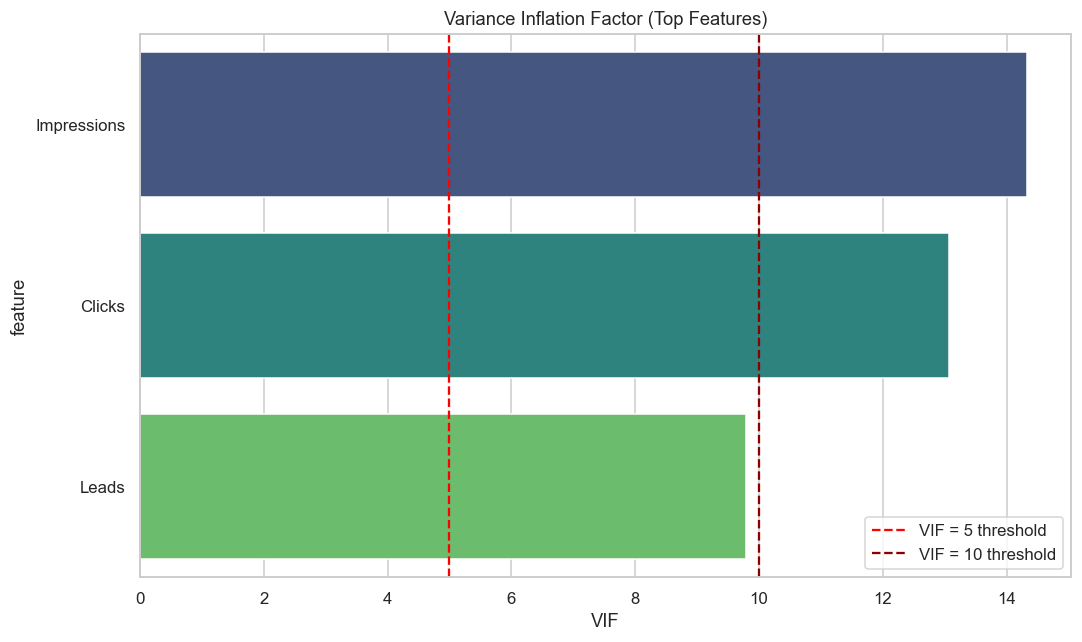

In [39]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame({'feature': X_train.columns})
vif_df['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif_df = vif_df.sort_values('VIF', ascending=False)
print(vif_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=vif_df.head(12), x='VIF', y='feature', palette='viridis')
plt.axvline(5, color='red', linestyle='--', label='VIF = 5 threshold')
plt.axvline(10, color='darkred', linestyle='--', label='VIF = 10 threshold')
plt.title('Variance Inflation Factor (Top Features)')
plt.legend()
plt.tight_layout()
plt.show()


## 8. Model Comparison

                         Model        R2      RMSE
0  Baseline OLS (all features) -0.006301  2.293583
1        Polynomial (degree 2) -0.004589  2.291632
2            Interaction terms -0.005629  2.292818


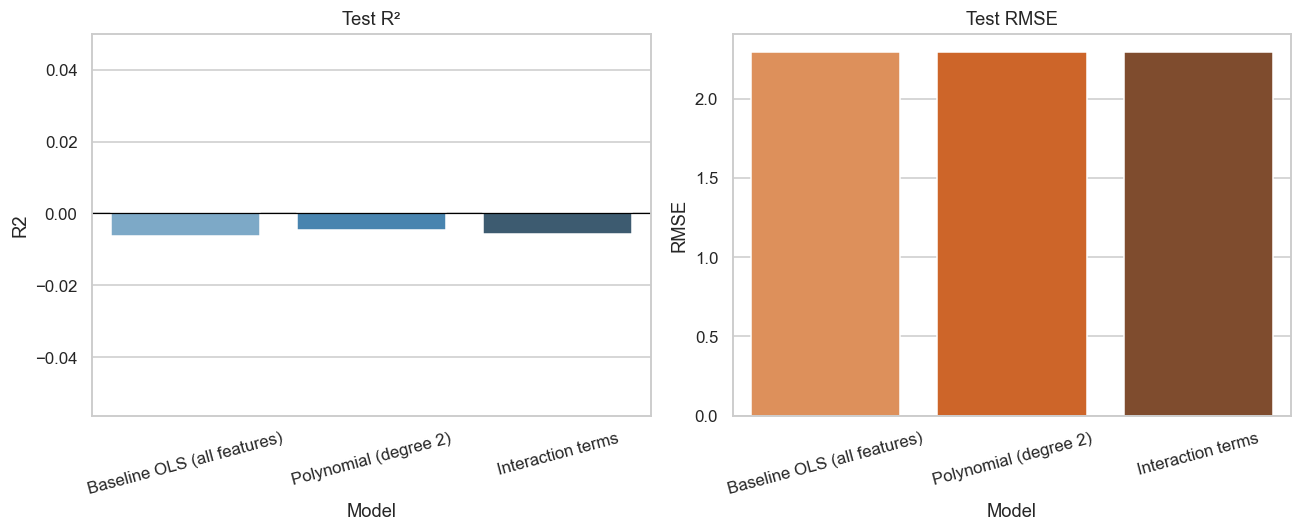

In [40]:

comparison = pd.DataFrame([
    {'Model': 'Baseline OLS (all features)', **metrics_ols},
    {'Model': 'Polynomial (degree 2)', **metrics_poly},
    {'Model': 'Interaction terms', **metrics_inter},
])
print(comparison)


from pathlib import Path
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)
plt.figure(figsize=(8, 6))

sns.barplot(data=comparison, x='Model', y='R2', palette='Blues_d')
r2_min = min(0, comparison['R2'].min() - 0.05)
plt.ylim(r2_min, max(0.05, comparison['R2'].max() + 0.05))
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Week 1 Model Comparison (Test R²)')
plt.xlabel('Model')
plt.ylabel('Test R²')
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig(FIG_DIR / 'figure1.png', bbox_inches='tight', dpi=160)
plt.close()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=comparison, x='Model', y='R2', ax=axes[0], palette='Blues_d')
r2_min = min(0, comparison['R2'].min() - 0.05)
axes[0].set_ylim(r2_min, max(0.05, comparison['R2'].max() + 0.05))
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Test R²')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(data=comparison, x='Model', y='RMSE', ax=axes[1], palette='Oranges_d')
axes[1].set_title('Test RMSE')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


## 9. Conclusions

**EDA insights:** Using the **Google Ads Sales** dataset with target `Conversions`, EDA showed that Clicks, Impressions, Leads, and `Conversion Rate` are related to conversion volume. However, `Conversion Rate` is partly derived from conversions, so it should be treated as a descriptive campaign-efficiency metric rather than a clean pre-outcome predictor.

**Baseline OLS:** The full linear model achieved test R² ≈ 0.36 (RMSE ≈ 1.83) in the saved Week 1 run. This numeric result is accurate for the features used in the notebook, but it likely overstates true predictive value because `Conversion Rate` was included.

**Polynomial & interaction terms:** The polynomial model (R² ≈ 0.26, RMSE ≈ 1.97) underperformed baseline OLS. This suggests that adding degree-2 terms did not improve generalization, even with the stronger target-related features included.

**Multicollinearity:** The high condition number in the OLS summary and elevated VIF values indicate multicollinearity among campaign metrics. This supports the later use of regularization in Week 2.

**Corrected marketing implication:** The Week 1 results are useful for descriptive analysis, but the conclusion should not be that conversions can be strongly predicted from available pre-campaign inputs. For Milestone 1, the cleaner conclusion is that conversion rate and clicks explain conversion volume descriptively, while leakage-free prediction is much weaker.